<div style="text-align: right; font-weight: bold;">
東京工科大学コンピュータサイエンス学部<br>
福西広晃
</div>

----

# 画像検索の概要

- 画像検索では、複数の画像の中から、**特定の対象が写っている画像を自動的に見つける**処理を行う。

- 今回は、Google Driveに保存されている複数のjpg画像を読み込み、AIを利用して画像の内容を判定する。

- 最初に、指定したフォルダ内の**すべてのjpg画像を読み込み、画像を確認する**。

- 次に、学習済みの画像分類モデルを利用して、読み込んだ画像の中から**猫が写っている画像を検出する**。
  - 猫と判定された画像を抽出する
  - 判定された種類を表示する
  - 判定の確率を表示する

- さらに、物体検出モデルを利用して、読み込んだ画像の中から**人が写っている画像を検出する**。
  - 人が写っている画像を抽出する
  - 画像内に写っている**人数を数える**
  - 検出結果と人数を表示する

- 本演習では、次の流れで画像データを分析する。
  1. **画像データの読み込み**
  2. **猫の画像を検出**
  3. **人の画像を検出**
  4. **画像内の人数を集計**

- このように、AIを利用することで、大量の画像を1枚ずつ人が確認しなくても、**画像の内容に基づいて必要な画像を自動的に検索・抽出することができる**。

# データの読み込み

**プロンプトの例**
「Google Driveの マイドライブ 内にある データ フォルダの中の 画像 フォルダに入っている jpgファイルを全て読み込んで、表示してください。」

# 猫の画像を検出

**プロンプトの例**
「読み込み済みの画像ファイルから猫の画像を検出し、表示してください」

# 人の画像を検出

**プロンプトの例**
「読み込み済みの画像ファイルから人の画像を検出し、表示してください。また、そのなかに含まれる人の数を表示してください。」

----
----
----
----
----
----
----
----
----
----

# プログラム例

## データの読み込み

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Searching for .jpg files in: /content/drive/My Drive/東京成徳大学特別講義/2026年度/第02回/データ/画像
Found 10 .jpg files. Displaying them now...
Displaying: 08_動物.jpg


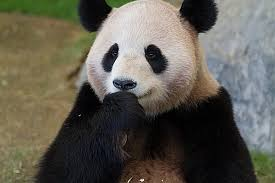

Displaying: 10_動物.jpg


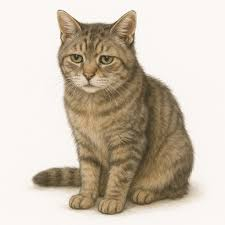

Displaying: 06_動物.jpg


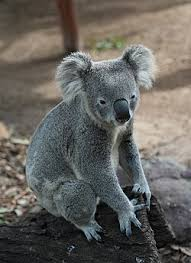

Displaying: 03_大学生.jpg


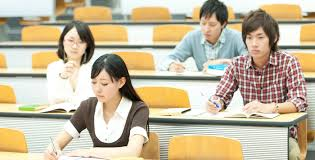

Displaying: 07_動物.jpg


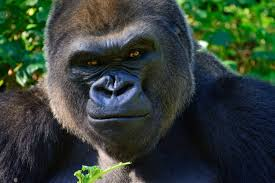

Displaying: 05_大学生.jpg


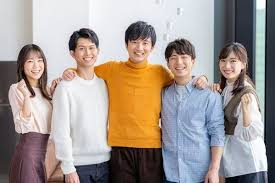

Displaying: 02_大学生.jpg


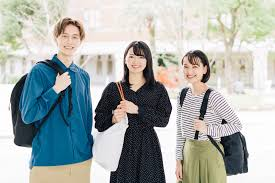

Displaying: 04_大学生.jpg


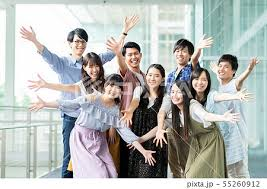

Displaying: 09_動物.jpg


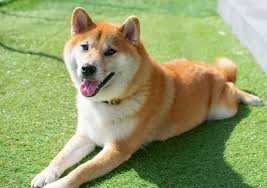

Displaying: 01_大学生.jpg


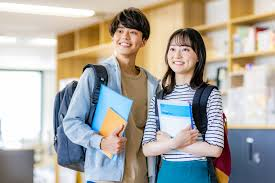

In [2]:
import os
import glob
from PIL import Image

# Google Driveのベースパス
base_drive_path = '/content/drive/My Drive'

# 対象フォルダのパスを作成
folder_path = os.path.join(base_drive_path, '東京成徳大学特別講義', '2026年度', '第02回', 'データ', '画像')

print(f"Searching for .jpg files in: {folder_path}")

# フォルダが存在するか確認
if not os.path.exists(folder_path):
    print(
        f"Error: The folder '{folder_path}' does not exist. "
        "Please check the path and your Google Drive structure."
    )

else:
    # jpgファイルを取得
    jpg_files = glob.glob(
        os.path.join(folder_path, '*.jpg')
    )

    if not jpg_files:
        print("No .jpg files found in the specified folder.")

    else:
        print(
            f"Found {len(jpg_files)} .jpg files. "
            "Displaying them now..."
        )

        # 取得した画像を表示
        for file_path in jpg_files:
            try:
                print(
                    f"Displaying: {os.path.basename(file_path)}"
                )

                img = Image.open(file_path)
                display(img)

            except Exception as e:
                print(
                    f"Could not open or display "
                    f"{file_path}: {e}"
                )

# 猫の画像を検出

MobileNetV2モデルを読み込んでいます...
MobileNetV2モデルを読み込みました。
10枚の画像を分類します。

猫と判定された画像：1枚


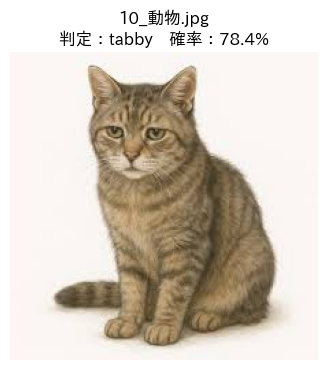

In [3]:
!pip install -q matplotlib_fontja

import os
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib_fontja

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input,
    decode_predictions
)

# 日本語表示を有効化
matplotlib_fontja.japanize()

# -----------------------------
# 1. MobileNetV2モデルを読み込む
# -----------------------------

print("MobileNetV2モデルを読み込んでいます...")

classifier = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=True
)

print("MobileNetV2モデルを読み込みました。")

# -----------------------------
# 2. 取得済みの画像ファイルを確認
# -----------------------------

# 前のセルで取得した jpg_files をそのまま使用
print(f"{len(jpg_files)}枚の画像を分類します。\n")

# -----------------------------
# 3. 猫に該当するImageNetクラス
# -----------------------------

cat_classes = {
    "tabby",
    "tiger_cat",
    "Persian_cat",
    "Siamese_cat",
    "Egyptian_cat"
}

cat_images = []

# -----------------------------
# 4. すべての画像を分類
# -----------------------------

for file_path in jpg_files:

    # 画像を224×224で読み込む
    img = tf.keras.utils.load_img(
        file_path,
        target_size=(224, 224)
    )

    # NumPy配列に変換
    img_array = tf.keras.utils.img_to_array(img)

    # バッチ次元を追加
    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # MobileNetV2用の前処理
    img_array = preprocess_input(
        img_array
    )

    # 画像分類
    predictions = classifier.predict(
        img_array,
        verbose=0
    )

    # 上位5件の分類結果
    results = decode_predictions(
        predictions,
        top=5
    )[0]

    # 上位5件に猫のクラスが含まれるか確認
    for _, label, probability in results:

        if label in cat_classes:

            cat_images.append(
                (file_path, label, probability)
            )

            break

# -----------------------------
# 5. 猫と判定された画像を表示
# -----------------------------

print(
    f"猫と判定された画像：{len(cat_images)}枚"
)

for file_path, label, probability in cat_images:

    img = Image.open(file_path)

    plt.figure(figsize=(5, 4))

    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"{os.path.basename(file_path)}\n"
        f"判定：{label}　確率：{probability:.1%}"
    )

    plt.show()

# 人の画像を検出

人物検出モデルを読み込みました。
10枚の画像を確認します。
人が写っている画像：5枚


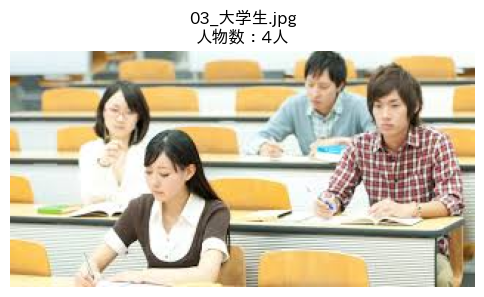

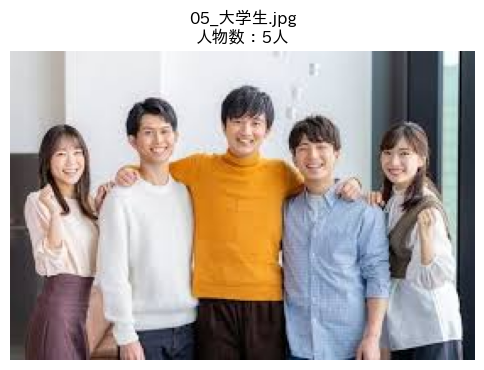

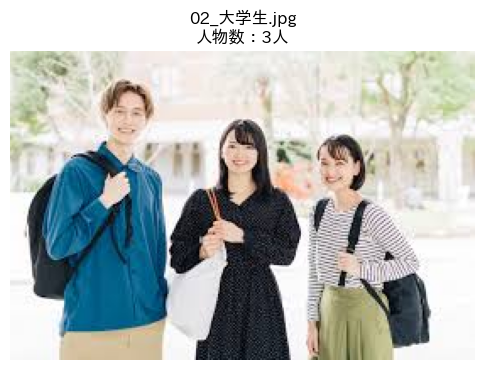

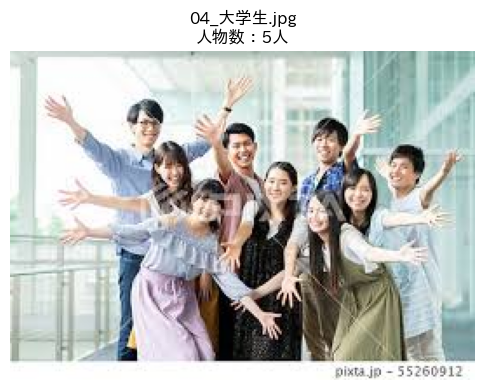

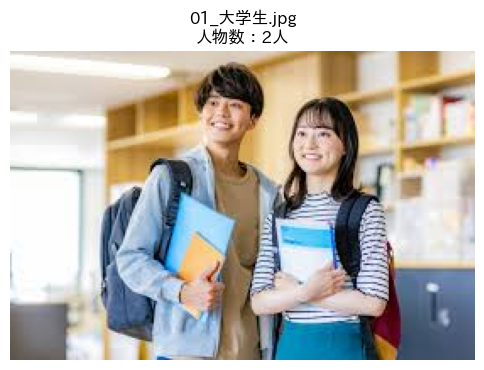

In [4]:
!pip install -q ultralytics

import os
import matplotlib.pyplot as plt
import matplotlib_fontja
from PIL import Image
from ultralytics import YOLO

# 日本語表示を有効化
matplotlib_fontja.japanize()

# -----------------------------
# 1. 人物検出モデルを読み込む
# -----------------------------
model = YOLO("yolo11n.pt")

print("人物検出モデルを読み込みました。")
print(f"{len(jpg_files)}枚の画像を確認します。")

# -----------------------------
# 2. 人が写っている画像を抽出
# -----------------------------
person_images = []

for file_path in jpg_files:

    # YOLOで物体検出
    results = model(
        file_path,
        conf=0.4,
        verbose=False
    )

    result = results[0]

    # 検出されたクラス番号を取得
    detected_classes = (
        result.boxes.cls
        .cpu()
        .numpy()
        .astype(int)
    )

    # YOLOでは class 0 が person
    person_count = int(
        (detected_classes == 0).sum()
    )

    # 人が1人以上写っている画像だけ保存
    if person_count > 0:
        person_images.append(
            (file_path, person_count)
        )

print(f"人が写っている画像：{len(person_images)}枚")

# -----------------------------
# 3. 人が写っている画像を表示
# -----------------------------
for file_path, person_count in person_images:

    image = Image.open(file_path)

    plt.figure(figsize=(6, 5))

    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"{os.path.basename(file_path)}\n"
        f"人物数：{person_count}人"
    )

    plt.show()